# LIBERO label prototypes — visual inspection

Compares two contact-distribution label representations against the raw contact cloud, per trial:

1. **Camera-projected 2D heatmaps** (`agentview`, `robot0_eye_in_hand`) — overlaid on `pre_rgb` and `robot0_eye_in_hand_rgb`, with raw contacts scattered on top for ground truth.
2. **3D voxel density** — three orthogonal max-projections (XY, XZ, YZ).

Run `scripts/libero/build_label_prototypes.py` first to produce `datasets/libero/v1/label_prototypes.npz`.

In [1]:
import os, sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mujoco

REPO_ROOT = Path(os.getcwd()).parent
os.chdir(REPO_ROOT)
sys.path.insert(0, str(REPO_ROOT))

from planner.experiments.libero.adapter import load_demo, materialise_mjcf
from planner.experiments.libero.naming import resolve_model_handles

LABELS_PATH = REPO_ROOT / "datasets/libero/v1/label_prototypes.npz"
V1_ROOT = REPO_ROOT / "datasets/libero/v1"
RAW_ROOT = REPO_ROOT / "datasets/libero/raw"

# Concat manifests across all splits — prototype trials may come from any of them.
manifest_parts = []
for split in ["libero_spatial", "libero_goal", "libero_object"]:
    p = V1_ROOT / split / "manifest.csv"
    if p.exists():
        manifest_parts.append(pd.read_csv(p))
manifest = pd.concat(manifest_parts, ignore_index=True).set_index("experiment_id")

labels = np.load(LABELS_PATH)
exp_ids = list(labels["experiment_id"])
bounds = labels["voxel_bounds"]
voxel_cm = float(labels["voxel_cm"])
print(f"loaded {len(exp_ids)} prototype trials  ({len(labels['group_keys'])} groups)")
print(f"voxel grid shape={labels['voxel_density'].shape[1:]}  bounds={bounds}  cm={voxel_cm}")
splits = manifest.loc[exp_ids, "split"].value_counts()
print(f"splits represented: {dict(splits)}")

loaded 33 prototype trials  (12 groups)
voxel grid shape=(52, 32, 35)  bounds=[[-0.7   0.35]
 [-0.4   0.55]
 [-0.2   1.35]]  cm=3.0
splits represented: {'libero_goal': np.int64(12), 'libero_object': np.int64(12), 'libero_spatial': np.int64(9)}


## Mass-conservation summary

For each trial, the smoothed label sum should equal the sum of in-frame/in-bounds contact weights (Gaussian smoothing is mass-preserving up to boundary truncation).

In [2]:
rows = []
for i, eid in enumerate(exp_ids):
    rec = manifest.loc[eid]
    tw = float(labels["total_weight"][i])
    rows.append(dict(
        i=i,
        task=rec["task"][:40],
        demo=rec["demo_key"],
        failure=rec["failure_mode"],
        n_contacts=int(rec["num_contacts"]),
        total_w=tw,
        agent_w=float(labels["weight_in_frame_agentview"][i]),
        agent_sum=float(labels["cam_heatmap_agentview"][i, ..., 0].sum()),
        eye_w=float(labels["weight_in_frame_eye_in_hand"][i]),
        eye_sum=float(labels["cam_heatmap_eye_in_hand"][i, ..., 0].sum()),
        vox_w=float(labels["weight_in_bounds_voxel"][i]),
        vox_sum=float(labels["voxel_density"][i].sum()),
    ))
summary = pd.DataFrame(rows)
summary["agent_ratio"] = summary["agent_sum"] / summary["agent_w"].clip(1e-9)
summary["eye_ratio"] = summary["eye_sum"] / summary["eye_w"].clip(1e-9)
summary["vox_ratio"] = summary["vox_sum"] / summary["vox_w"].clip(1e-9)
summary

,i,task,demo,failure,n_contacts,total_w,agent_w,agent_sum,eye_w,eye_sum,vox_w,vox_sum,agent_ratio,eye_ratio,vox_ratio
0,0,pick_up_the_black_bowl_between_the_plate,demo_24,SLIPPERY_GRIP,44,29.141535,29.141535,29.141535,20.654510,20.654510,29.141535,29.141129,1.000000,1.000000,0.999986
1,1,pick_up_the_black_bowl_between_the_plate,demo_24,MULTI_JOINT,11402,8297.639648,8297.639648,8297.639648,6155.737305,6129.568848,8297.639648,8297.607422,1.000000,0.995749,0.999996
2,2,pick_up_the_black_bowl_between_the_plate,demo_24,SLIPPERY_GRIP,461,338.502502,338.502502,338.502502,247.072006,246.010651,338.502502,338.501892,1.000000,0.995704,0.999998
3,3,pick_up_the_black_bowl_in_the_top_drawer,demo_3,MULTI_JOINT,7327,7820.302734,7820.302734,7820.301758,7820.302734,7820.301758,7820.302734,7819.927734,1.000000,1.000000,0.999952
4,4,pick_up_the_black_bowl_in_the_top_drawer,demo_3,MULTI_JOINT,5990,7506.354004,7506.354004,7506.354492,7506.354004,7506.353027,7506.354004,7505.430176,1.000000,1.000000,0.999877
5,5,pick_up_the_black_bowl_in_the_top_drawer,demo_3,GRIPPER_OPEN,14,27.913368,27.913368,27.913368,27.913368,27.913372,27.913368,27.892805,1.000000,1.000000,0.999263
6,6,pick_up_the_black_bowl_next_to_the_ramek,demo_20,SINGLE_JOINT,302,5897.044434,5897.044434,5897.043457,5897.044434,5897.043945,5897.044434,5897.043945,1.000000,1.000000,1.000000
7,7,pick_up_the_black_bowl_next_to_the_ramek,demo_20,SINGLE_JOINT,291,6015.128418,6015.128418,6015.128906,6015.128418,6015.127930,6015.128418,6015.129395,1.000000,1.000000,1.000000
8,8,pick_up_the_black_bowl_on_the_wooden_cab,demo_47,SINGLE_JOINT,685,7975.435059,7975.435059,7975.435059,7975.435059,7975.436035,7975.435059,7975.436035,1.000000,1.000000,1.000000
9,9,open_the_middle_drawer_of_the_cabinet,demo_14,GRIPPER_OPEN,44,135.685699,135.685699,135.685715,135.685699,135.685699,135.685699,135.685715,1.000000,1.000000,1.000000


## Pick a trial to inspect

In [3]:
# Find a trial with a healthy mix of contacts visible in both cameras.
interesting = summary[(summary["agent_w"] > 50) & (summary["eye_w"] > 50)].sort_values("total_w", ascending=False)
print(interesting[["i", "task", "failure", "n_contacts", "agent_w", "eye_w", "vox_w"]].head(10))

TRIAL_IDX = int(interesting.iloc[0]["i"])
eid = exp_ids[TRIAL_IDX]
rec = manifest.loc[eid]
print(f"\ninspecting trial {TRIAL_IDX}: {eid}")
print(f"  split={rec['split']}  task={rec['task']}  demo={rec['demo_key']}  failure={rec['failure_mode']}")

# Reload the trial's npz + MJCF + camera handles so we can re-project raw contacts.
trial_npz = V1_ROOT / rec["split"] / rec["npz_file"]
trial = dict(np.load(trial_npz))
hdf5_path = RAW_ROOT / rec["split"] / f"{rec['task']}_demo.hdf5"
demo = load_demo(str(hdf5_path), demo_key=rec["demo_key"])
model = mujoco.MjModel.from_xml_path(materialise_mjcf(demo.model_xml))
handles = resolve_model_handles(model)

# Re-build the MjData state that produced the camera poses used at label time.
data = mujoco.MjData(model)
if demo.full_states is not None:
    data.qpos[:] = demo.full_states[0, 1:1 + model.nq]
for k, adr in enumerate(handles.arm_qpos_adrs):
    data.qpos[adr] = trial["pre_qpos"][k]
mujoco.mj_forward(model, data)
print(f"  cameras: agentview={handles.agentview_cam}  eye_in_hand={handles.ee_cam}")

     i                                      task       failure  n_contacts  \
16  16           put_the_wine_bottle_on_the_rack  SINGLE_JOINT        5476   
28  28  pick_up_the_salad_dressing_and_place_it_  SINGLE_JOINT        4509   
10  10     open_the_middle_drawer_of_the_cabinet  SINGLE_JOINT        1500   
11  11     open_the_middle_drawer_of_the_cabinet  SINGLE_JOINT        1494   
1    1  pick_up_the_black_bowl_between_the_plate   MULTI_JOINT       11402   
8    8  pick_up_the_black_bowl_on_the_wooden_cab  SINGLE_JOINT         685   
3    3  pick_up_the_black_bowl_in_the_top_drawer   MULTI_JOINT        7327   
4    4  pick_up_the_black_bowl_in_the_top_drawer   MULTI_JOINT        5990   
25  25  pick_up_the_orange_juice_and_place_it_in    ALL_JOINTS        5302   
7    7  pick_up_the_black_bowl_next_to_the_ramek  SINGLE_JOINT         291   

         agent_w         eye_w         vox_w  
16  17135.589844  16992.060547  17135.589844  
28  12145.595703  11781.319336  12145.595703  


  cameras: agentview=agentview  eye_in_hand=robot0_eye_in_hand


## Camera overlays: heatmap + raw contact scatter

Left column: smoothed heatmap on top of the RGB. Right column: raw contacts re-projected as red dots. The peaks of the heatmap should sit on top of the scattered contacts (within σ pixels).

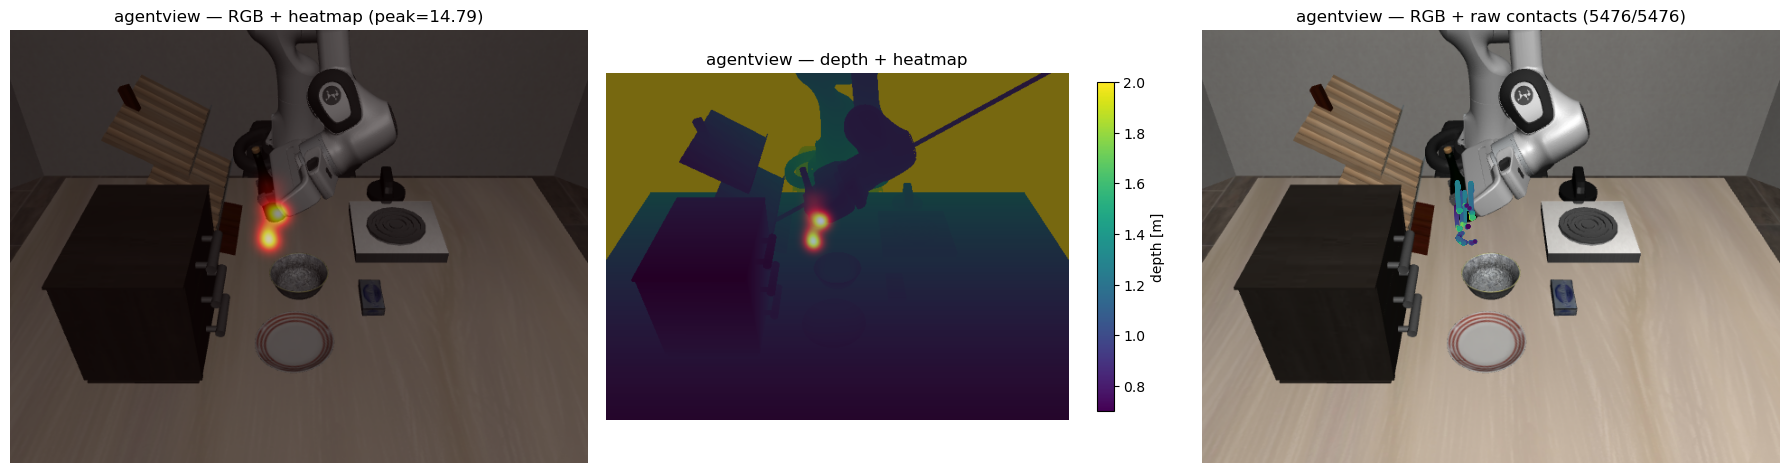

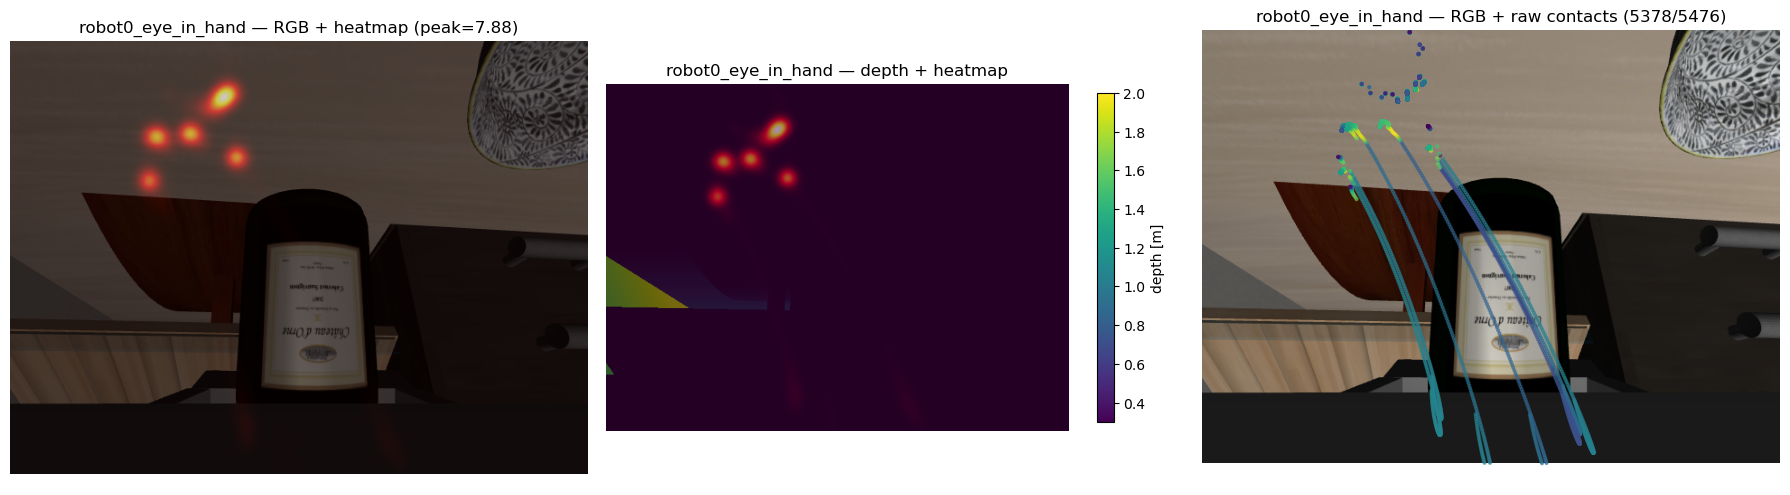

In [4]:
from planner.risk.projection_labels import _DynamicCameraProjector

def _depth_to_display(depth, lo=0.3, hi=2.0):
    """Clip depth to a sensible range so the workspace surface is well-resolved."""
    return np.clip(depth, lo, hi)

def overlay_triplet(rgb, depth_frame, heatmap, cam_name, title):
    """Three panels per camera: RGB+heatmap, depth-frame+heatmap, RGB+raw contacts."""
    mass = heatmap if heatmap.ndim == 2 else heatmap[..., 0]
    vmax = mass.max() if mass.max() > 0 else 1.0
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # 1) RGB + heatmap.
    axes[0].imshow(rgb)
    if mass.max() > 0:
        axes[0].imshow(mass, cmap="hot", alpha=0.55, vmin=0, vmax=vmax)
    axes[0].set_title(f"{title} — RGB + heatmap (peak={mass.max():.2f})")
    axes[0].axis("off")

    # 2) Depth frame + same heatmap overlay. Same vmax as panel 1 so peaks align.
    d_show = _depth_to_display(depth_frame)
    im = axes[1].imshow(d_show, cmap="viridis")
    if mass.max() > 0:
        axes[1].imshow(mass, cmap="hot", alpha=0.55, vmin=0, vmax=vmax)
    plt.colorbar(im, ax=axes[1], label="depth [m]", shrink=0.7)
    axes[1].set_title(f"{title} — depth + heatmap")
    axes[1].axis("off")

    # 3) RGB + raw contact scatter (ground-truth comparison).
    axes[2].imshow(rgb)
    cp = trial["contact_positions"]
    if cp.shape[0] > 0:
        proj = _DynamicCameraProjector(model, data, cam_name,
                                       width=rgb.shape[1], height=rgb.shape[0])
        px, depth = proj.project(cp)
        mask = proj.in_frame(px, depth)
        fmag = np.linalg.norm(trial["contact_forces"][:, :3], axis=1)
        axes[2].scatter(px[mask, 0], px[mask, 1],
                        c=np.log10(fmag[mask] + 1e-3), s=4, cmap="viridis", alpha=0.55)
        axes[2].set_title(f"{title} — RGB + raw contacts ({mask.sum()}/{cp.shape[0]})")
    else:
        axes[2].set_title(f"{title} — no contacts")
    axes[2].axis("off")
    plt.tight_layout()

overlay_triplet(trial["pre_rgb"],
                trial["pre_depth"],
                labels["cam_heatmap_agentview"][TRIAL_IDX],
                handles.agentview_cam, "agentview")
overlay_triplet(trial["robot0_eye_in_hand_rgb"],
                trial["robot0_eye_in_hand_depth"],
                labels["cam_heatmap_eye_in_hand"][TRIAL_IDX],
                handles.ee_cam, "robot0_eye_in_hand")

## Voxel density — three orthogonal max-projections

Each panel collapses one axis with a max-projection and overlays the raw contact points for ground-truth comparison. Axes are in world-frame metres; dashed line marks the table z-floor of the prototype bounds.

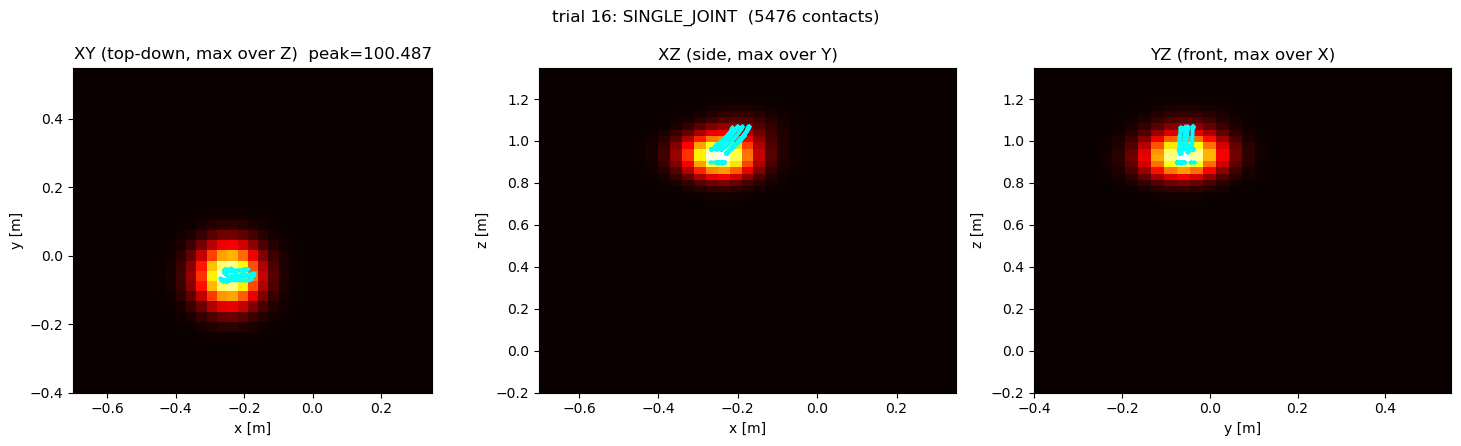

In [5]:
vox = labels["voxel_density"][TRIAL_IDX]
x_min, x_max = bounds[0]
y_min, y_max = bounds[1]
z_min, z_max = bounds[2]
cp = trial["contact_positions"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# Top-down (XY): collapse Z axis (axis 0 in (nz, ny, nx)).
axes[0].imshow(vox.max(axis=0), origin="lower", cmap="hot",
               extent=(x_min, x_max, y_min, y_max), aspect="equal")
if cp.shape[0] > 0:
    axes[0].scatter(cp[:, 0], cp[:, 1], s=2, c="cyan", alpha=0.4)
axes[0].set_title(f"XY (top-down, max over Z)  peak={vox.max():.3f}")
axes[0].set_xlabel("x [m]"); axes[0].set_ylabel("y [m]")

# Side (XZ): collapse Y axis (axis 1).
axes[1].imshow(vox.max(axis=1), origin="lower", cmap="hot",
               extent=(x_min, x_max, z_min, z_max), aspect="auto")
if cp.shape[0] > 0:
    axes[1].scatter(cp[:, 0], cp[:, 2], s=2, c="cyan", alpha=0.4)
axes[1].set_title("XZ (side, max over Y)")
axes[1].set_xlabel("x [m]"); axes[1].set_ylabel("z [m]")

# Front (YZ): collapse X axis (axis 2).
axes[2].imshow(vox.max(axis=2), origin="lower", cmap="hot",
               extent=(y_min, y_max, z_min, z_max), aspect="auto")
if cp.shape[0] > 0:
    axes[2].scatter(cp[:, 1], cp[:, 2], s=2, c="cyan", alpha=0.4)
axes[2].set_title("YZ (front, max over X)")
axes[2].set_xlabel("y [m]"); axes[2].set_ylabel("z [m]")

plt.suptitle(f"trial {TRIAL_IDX}: {rec['failure_mode']}  ({cp.shape[0]} contacts)")
plt.tight_layout()

## Sanity panel — out-of-frame / out-of-bounds rates across the prototype subset

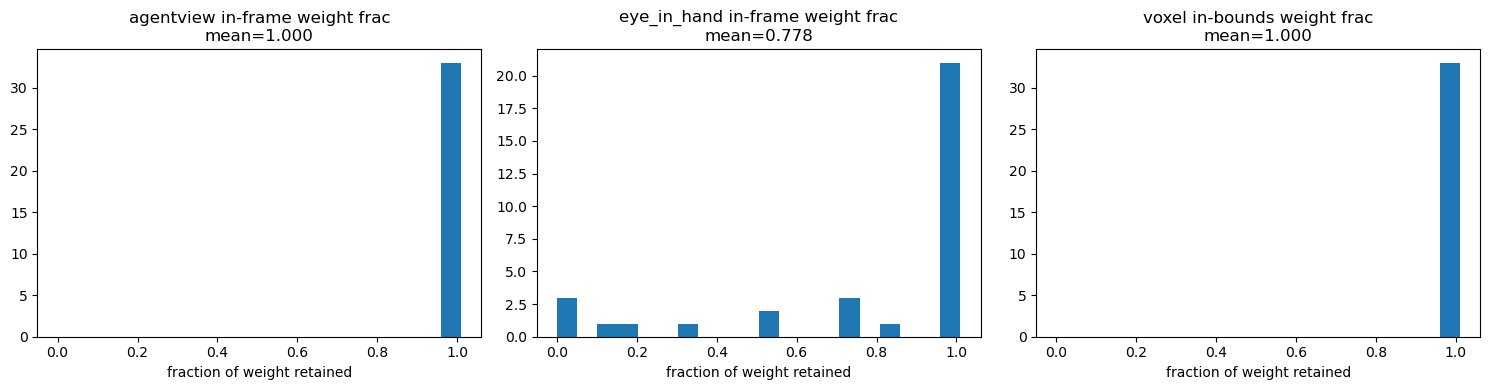

In [6]:
valid = summary[summary["total_w"] > 0].copy()
valid["agent_in_frame_frac"] = valid["agent_w"] / valid["total_w"]
valid["eye_in_frame_frac"] = valid["eye_w"] / valid["total_w"]
valid["vox_in_bounds_frac"] = valid["vox_w"] / valid["total_w"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(valid["agent_in_frame_frac"], bins=20, range=(0, 1.01))
axes[0].set_title(f"agentview in-frame weight frac\nmean={valid['agent_in_frame_frac'].mean():.3f}")
axes[1].hist(valid["eye_in_frame_frac"], bins=20, range=(0, 1.01))
axes[1].set_title(f"eye_in_hand in-frame weight frac\nmean={valid['eye_in_frame_frac'].mean():.3f}")
axes[2].hist(valid["vox_in_bounds_frac"], bins=20, range=(0, 1.01))
axes[2].set_title(f"voxel in-bounds weight frac\nmean={valid['vox_in_bounds_frac'].mean():.3f}")
for ax in axes:
    ax.set_xlabel("fraction of weight retained")
plt.tight_layout()

# Round 2 — depth channel, log1p compression, and per-pre-state aggregates

The cells below visualise the additional label variants written by `build_label_prototypes.py` after Round 2: the depth channel of the camera heatmap, the raw-vs-`log1p` dynamic-range comparison, and the per-pre-state aggregate that averages all sibling failure trials for a single (demo, bin_idx).

label vs observed depth at high-mass pixels (n=3468):
  label:    mean=1.103  range=[1.008, 1.148] m
  observed: mean=1.080  range=[0.913, 1.317] m
  label - observed:  mean=+0.023  std=0.086 m
  (label_depth is the back-projected contact depth; observed is the visible scene surface.
   They match exactly if contacts hit visible surfaces; differ if contacts are inside objects.)


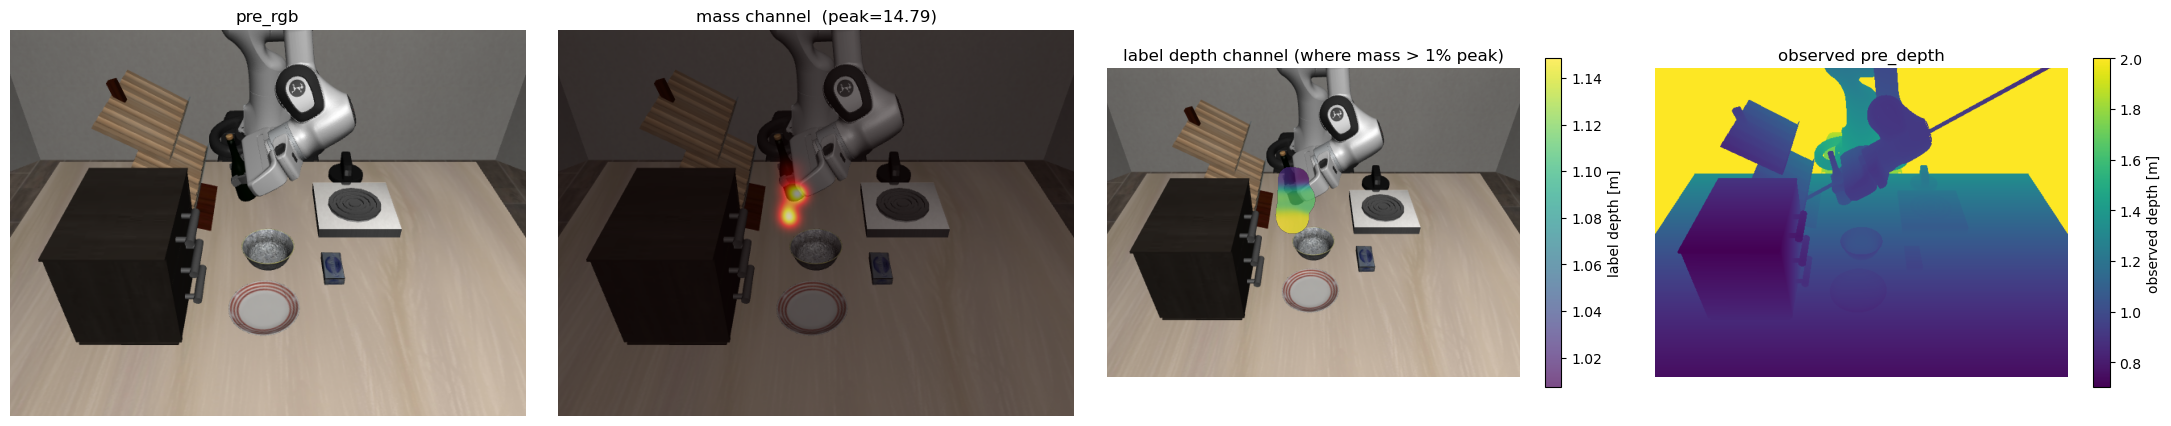

In [7]:
# 1) Depth channel inspection — compare label depth vs observed depth frame.
cam = labels["cam_heatmap_agentview"][TRIAL_IDX]   # (H, W, 2)
mass = cam[..., 0]
depth_label = cam[..., 1]
depth_obs = trial["pre_depth"]

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
axes[0].imshow(trial["pre_rgb"]); axes[0].set_title("pre_rgb"); axes[0].axis("off")

axes[1].imshow(trial["pre_rgb"])
if mass.max() > 0:
    axes[1].imshow(mass, cmap="hot", alpha=0.55, vmin=0, vmax=mass.max())
axes[1].set_title(f"mass channel  (peak={mass.max():.2f})"); axes[1].axis("off")

# Label depth channel — only meaningful where mass is non-trivial.
depth_show = np.where(mass > 0.01 * mass.max(), depth_label, np.nan)
nz = np.any(~np.isnan(depth_show))
im2 = axes[2].imshow(trial["pre_rgb"])
im2 = axes[2].imshow(depth_show, cmap="viridis", alpha=0.7,
                     vmin=np.nanmin(depth_show) if nz else 0,
                     vmax=np.nanmax(depth_show) if nz else 1)
plt.colorbar(im2, ax=axes[2], label="label depth [m]", shrink=0.7)
axes[2].set_title("label depth channel (where mass > 1% peak)"); axes[2].axis("off")

# Observed depth frame (from MuJoCo renderer at trial time).
im3 = axes[3].imshow(np.clip(depth_obs, 0.3, 2.0), cmap="viridis")
plt.colorbar(im3, ax=axes[3], label="observed depth [m]", shrink=0.7)
axes[3].set_title("observed pre_depth"); axes[3].axis("off")
plt.tight_layout()

# Quantitative cross-check: label depth vs observed depth at high-mass pixels.
if nz:
    hi_mass = mass > 0.05 * mass.max()
    if hi_mass.any():
        label_d = depth_label[hi_mass]
        obs_d = depth_obs[hi_mass]
        diff = label_d - obs_d
        print(f"label vs observed depth at high-mass pixels (n={hi_mass.sum()}):")
        print(f"  label:    mean={label_d.mean():.3f}  range=[{label_d.min():.3f}, {label_d.max():.3f}] m")
        print(f"  observed: mean={obs_d.mean():.3f}  range=[{obs_d.min():.3f}, {obs_d.max():.3f}] m")
        print(f"  label - observed:  mean={diff.mean():+.3f}  std={diff.std():.3f} m")
        print(f"  (label_depth is the back-projected contact depth; observed is the visible scene surface.")
        print(f"   They match exactly if contacts hit visible surfaces; differ if contacts are inside objects.)")

raw mass dynamic range over nonzero pixels: 1.006e-06 – 1.479e+01  (ratio = 14698711x)
log1p compressed range: 0.000 – 2.760


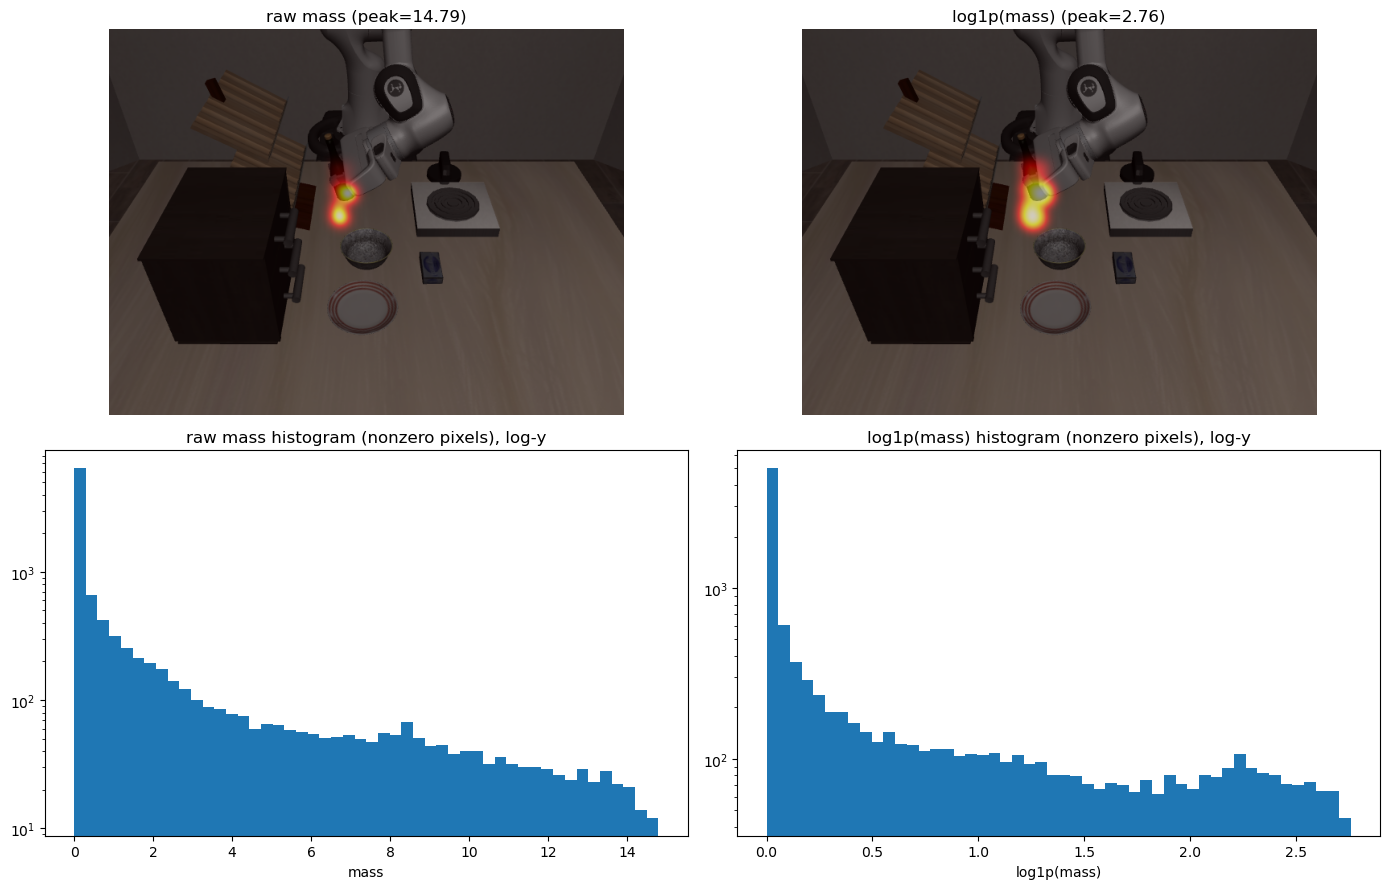

In [8]:
# 2) Raw vs log1p comparison for the agentview mass channel.
mass_raw = labels["cam_heatmap_agentview"][TRIAL_IDX, ..., 0]
mass_log = labels["cam_heatmap_agentview_log1p"][TRIAL_IDX]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes[0, 0].imshow(trial["pre_rgb"])
axes[0, 0].imshow(mass_raw, cmap="hot", alpha=0.55,
                  vmin=0, vmax=mass_raw.max() if mass_raw.max() > 0 else 1)
axes[0, 0].set_title(f"raw mass (peak={mass_raw.max():.2f})")
axes[0, 0].axis("off")

axes[0, 1].imshow(trial["pre_rgb"])
axes[0, 1].imshow(mass_log, cmap="hot", alpha=0.55,
                  vmin=0, vmax=mass_log.max() if mass_log.max() > 0 else 1)
axes[0, 1].set_title(f"log1p(mass) (peak={mass_log.max():.2f})")
axes[0, 1].axis("off")

nz_raw = mass_raw[mass_raw > 1e-6]
nz_log = mass_log[mass_log > 1e-6]
if nz_raw.size > 0:
    axes[1, 0].hist(nz_raw, bins=50, log=True)
    axes[1, 0].set_title(f"raw mass histogram (nonzero pixels), log-y")
    axes[1, 0].set_xlabel("mass")
if nz_log.size > 0:
    axes[1, 1].hist(nz_log, bins=50, log=True)
    axes[1, 1].set_title(f"log1p(mass) histogram (nonzero pixels), log-y")
    axes[1, 1].set_xlabel("log1p(mass)")
plt.tight_layout()
print(f"raw mass dynamic range over nonzero pixels: "
      f"{nz_raw.min():.3e} – {nz_raw.max():.3e}  (ratio = {nz_raw.max()/nz_raw.min():.0f}x)")
print(f"log1p compressed range: {nz_log.min():.3f} – {nz_log.max():.3f}")

group 6  (libero_goal/put_the_wine_bottle_on_the_rack/demo_19/bin6)  n_trials=3


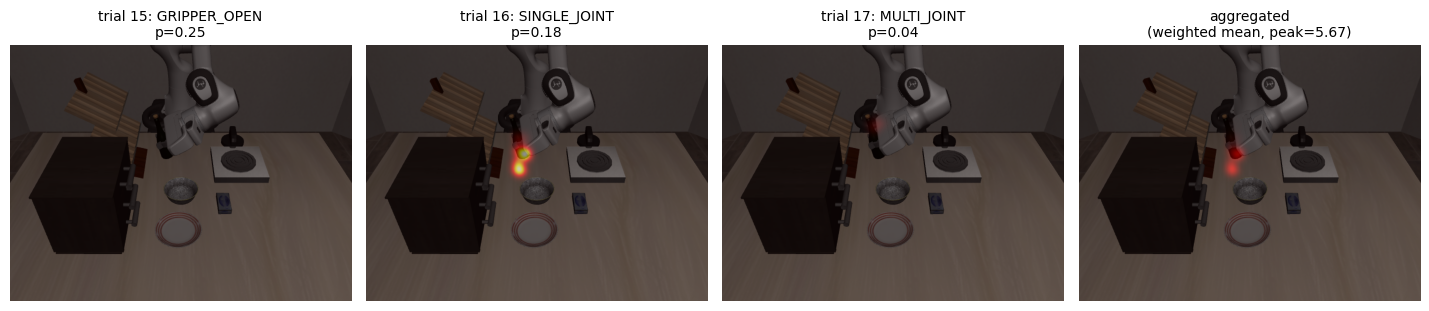

In [9]:
# 3) Per-trial vs aggregated label for one group.
# Pick the group containing TRIAL_IDX so the loaded pre_rgb backdrop matches.
group_ids = labels["group_ids"]
group_keys = labels["group_keys"]
group_n = labels["group_n_trials"]
GROUP_IDX = int(group_ids[TRIAL_IDX])
sibling_idxs = np.where(group_ids == GROUP_IDX)[0]
agg = labels["group_cam_heatmap_agentview"][GROUP_IDX]
print(f"group {GROUP_IDX}  ({group_keys[GROUP_IDX]})  n_trials={group_n[GROUP_IDX]}")
# All siblings share (demo, bin_idx), so pre_rgb at the failure step is the same
# kinematic frame for all of them; using `trial["pre_rgb"]` as backdrop is fine.

n = sibling_idxs.size
cols = max(2, n)
fig, axes = plt.subplots(1, cols + 1, figsize=(3.6 * (cols + 1), 4.0), squeeze=False)
vmax = max(labels["cam_heatmap_agentview"][i, ..., 0].max() for i in sibling_idxs)
vmax = max(vmax, agg.max())
for k, i in enumerate(sibling_idxs):
    m = labels["cam_heatmap_agentview"][i, ..., 0]
    fmode = manifest.loc[exp_ids[i], "failure_mode"]
    fprob = float(labels["failure_prob_per_trial"][i])
    axes[0, k].imshow(trial["pre_rgb"])
    if m.max() > 0:
        axes[0, k].imshow(m, cmap="hot", alpha=0.55, vmin=0, vmax=vmax)
    axes[0, k].set_title(f"trial {i}: {fmode}\np={fprob:.2f}", fontsize=10)
    axes[0, k].axis("off")
for k in range(n, cols):
    axes[0, k].axis("off")

axes[0, cols].imshow(trial["pre_rgb"])
if agg.max() > 0:
    axes[0, cols].imshow(agg, cmap="hot", alpha=0.55, vmin=0, vmax=vmax)
axes[0, cols].set_title(f"aggregated\n(weighted mean, peak={agg.max():.2f})", fontsize=10)
axes[0, cols].axis("off")
plt.tight_layout()

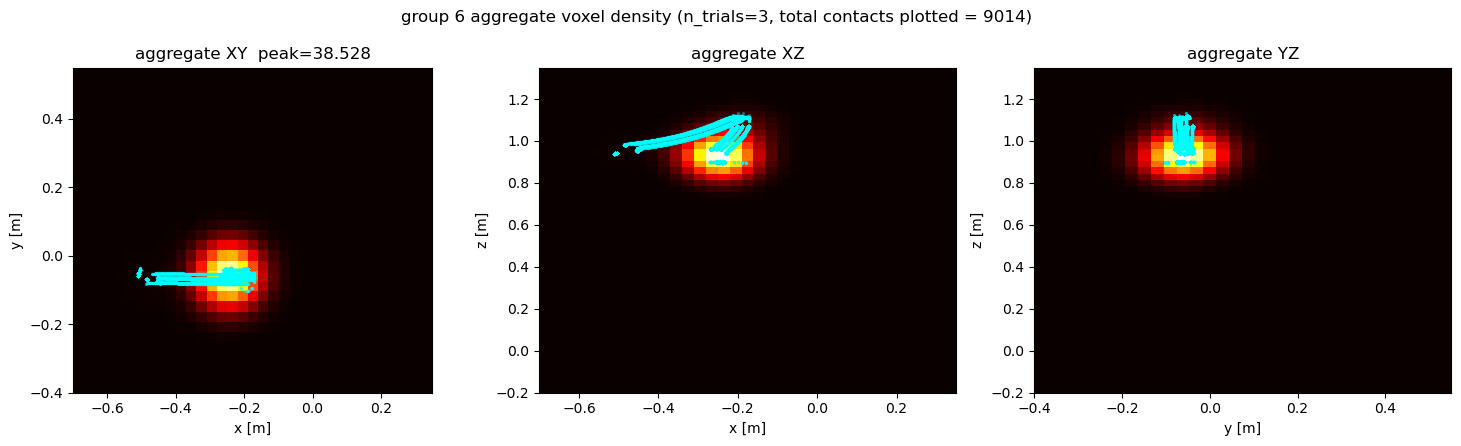

In [10]:
# 4) Voxel aggregate slices for the same group.
vox_agg = labels["group_voxel_density"][GROUP_IDX]
x_min, x_max = bounds[0]
y_min, y_max = bounds[1]
z_min, z_max = bounds[2]
# Union of all sibling contact clouds for the scatter overlay.
all_contacts = []
for i in sibling_idxs:
    rec_i = manifest.loc[exp_ids[i]]
    npz_i = REPO_ROOT / "datasets/libero/v1" / rec_i["split"] / rec_i["npz_file"]
    cp_i = np.load(npz_i)["contact_positions"]
    if cp_i.shape[0] > 0:
        all_contacts.append(cp_i)
all_contacts = np.concatenate(all_contacts, axis=0) if all_contacts else np.zeros((0, 3))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
axes[0].imshow(vox_agg.max(axis=0), origin="lower", cmap="hot",
               extent=(x_min, x_max, y_min, y_max), aspect="equal")
if all_contacts.shape[0] > 0:
    axes[0].scatter(all_contacts[:, 0], all_contacts[:, 1], s=2, c="cyan", alpha=0.3)
axes[0].set_title(f"aggregate XY  peak={vox_agg.max():.3f}")
axes[0].set_xlabel("x [m]"); axes[0].set_ylabel("y [m]")

axes[1].imshow(vox_agg.max(axis=1), origin="lower", cmap="hot",
               extent=(x_min, x_max, z_min, z_max), aspect="auto")
if all_contacts.shape[0] > 0:
    axes[1].scatter(all_contacts[:, 0], all_contacts[:, 2], s=2, c="cyan", alpha=0.3)
axes[1].set_title("aggregate XZ")
axes[1].set_xlabel("x [m]"); axes[1].set_ylabel("z [m]")

axes[2].imshow(vox_agg.max(axis=2), origin="lower", cmap="hot",
               extent=(y_min, y_max, z_min, z_max), aspect="auto")
if all_contacts.shape[0] > 0:
    axes[2].scatter(all_contacts[:, 1], all_contacts[:, 2], s=2, c="cyan", alpha=0.3)
axes[2].set_title("aggregate YZ")
axes[2].set_xlabel("y [m]"); axes[2].set_ylabel("z [m]")

plt.suptitle(f"group {GROUP_IDX} aggregate voxel density (n_trials={group_n[GROUP_IDX]}, "
             f"total contacts plotted = {all_contacts.shape[0]})")
plt.tight_layout()

# Multi-scene gallery

One row per trial across all represented splits/tasks. Columns:
1. **Agentview RGB + heatmap** — overall scene view with predicted contact density.
2. **Agentview depth + heatmap** — same heatmap on the depth frame so you can verify it lands on the visible surface.
3. **Wrist RGB + heatmap** — close-up view from the robot's hand camera.

Picks trials prioritising scene diversity (one per task), then highest `total_w` within each task as tiebreaker.

gallery: 11 trials across 3 splits


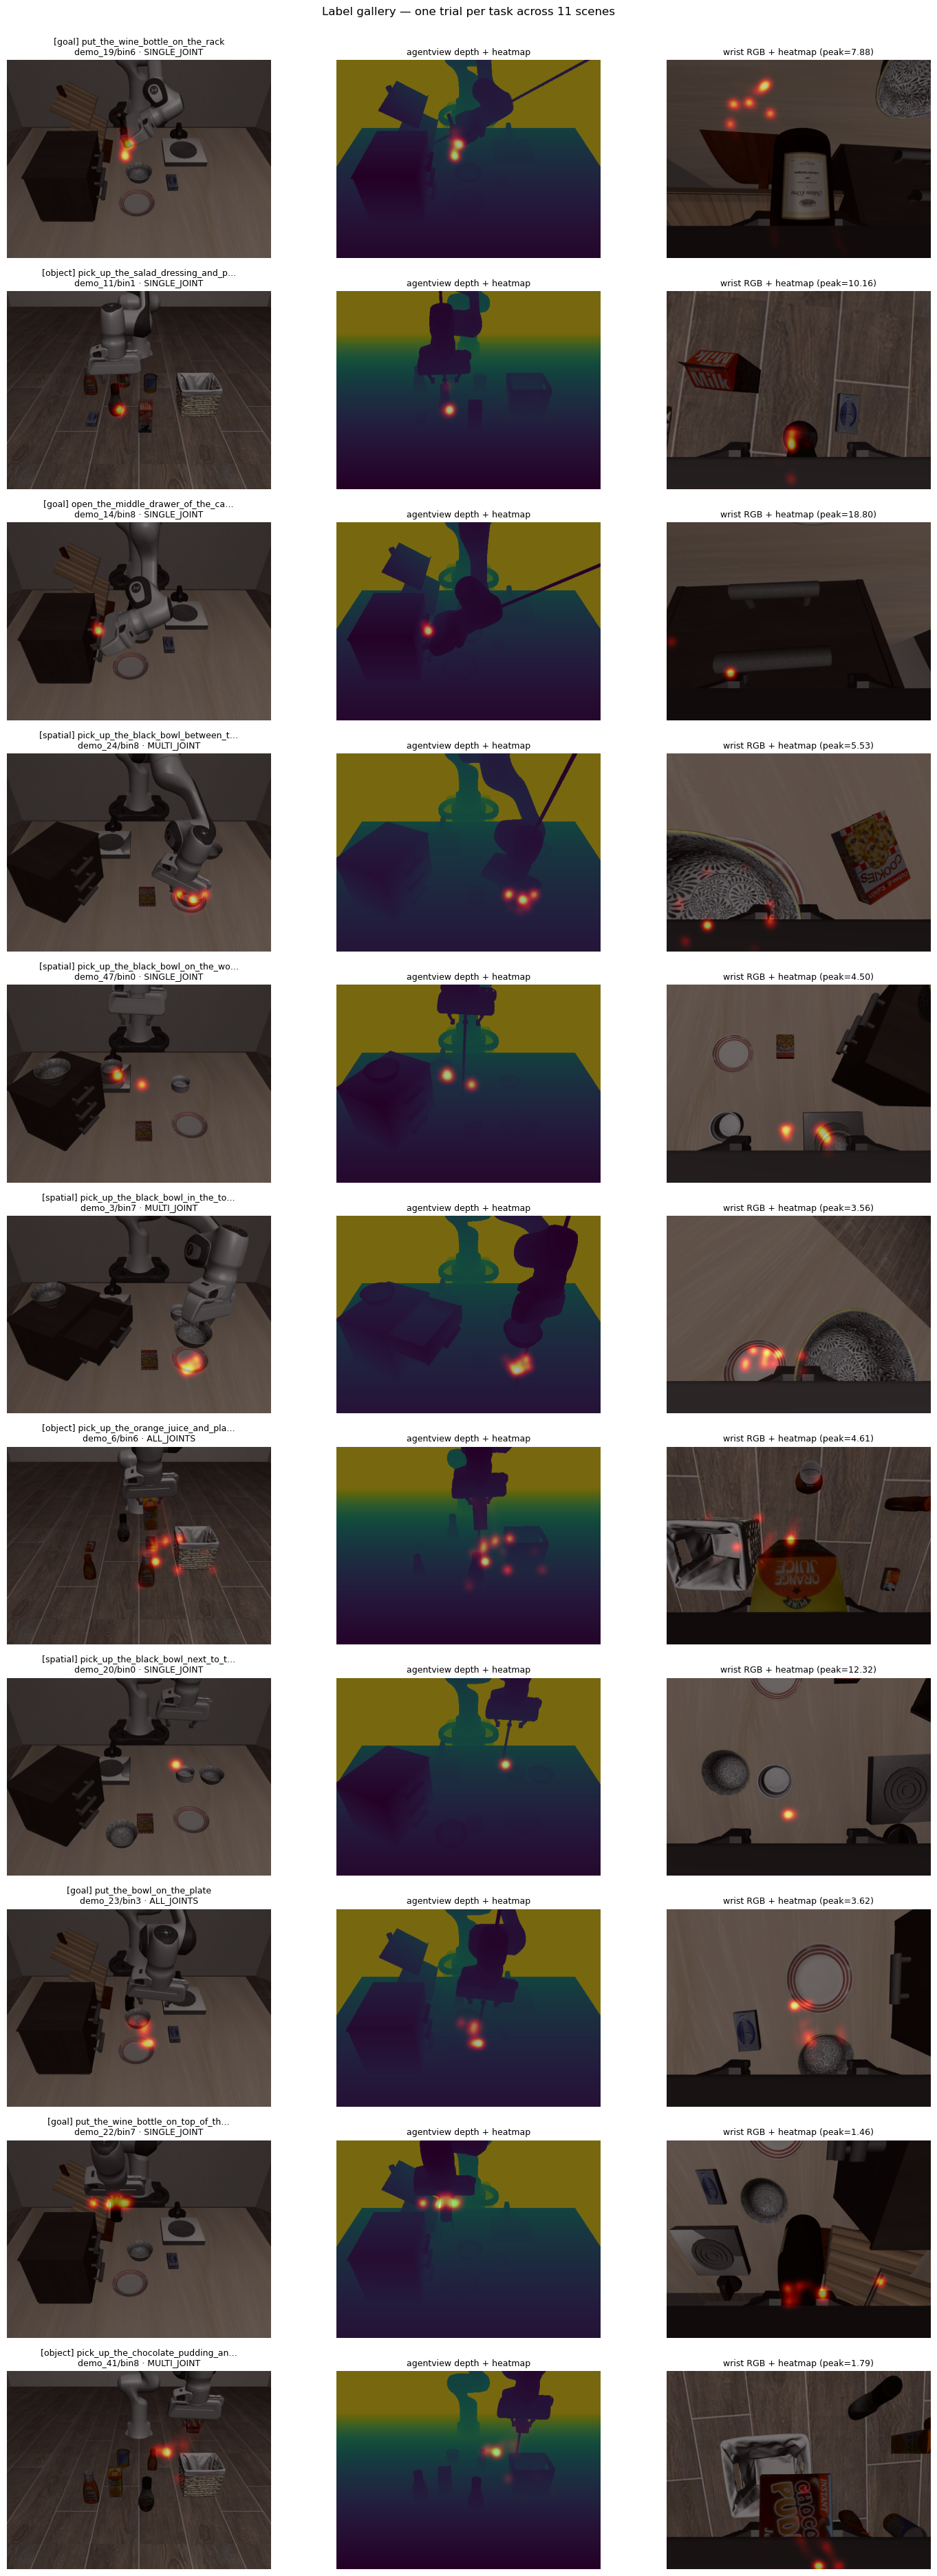

In [11]:
# Cache MJCF model + MjData per demo across trials in the gallery to avoid reloading.
_model_cache = {}

def _load_model_data_for(rec, pre_qpos):
    key = (rec["split"], rec["task"], rec["demo_key"])
    if key not in _model_cache:
        hdf5_path = RAW_ROOT / rec["split"] / f"{rec['task']}_demo.hdf5"
        demo_i = load_demo(str(hdf5_path), demo_key=rec["demo_key"])
        m = mujoco.MjModel.from_xml_path(materialise_mjcf(demo_i.model_xml))
        h = resolve_model_handles(m)
        init = demo_i.full_states[0, 1:1 + m.nq] if demo_i.full_states is not None else None
        _model_cache[key] = (m, h, init)
    m, h, init = _model_cache[key]
    d = mujoco.MjData(m)
    if init is not None:
        d.qpos[:] = init
    for k, adr in enumerate(h.arm_qpos_adrs):
        d.qpos[adr] = pre_qpos[k]
    mujoco.mj_forward(m, d)
    return m, h, d

# Pick one trial per task, prioritising those with highest total_w + non-empty
# in both cameras. Falls back to highest total_w if a task has no two-camera trial.
def _pick_one_per_task(summary_df, manifest_df):
    summary_df = summary_df.copy()
    summary_df["split"] = [manifest_df.loc[exp_ids[i], "split"] for i in summary_df["i"]]
    # Score: prioritise rows where both cams see contacts AND high total weight.
    summary_df["both_cams"] = (summary_df["agent_w"] > 1.0) & (summary_df["eye_w"] > 1.0)
    summary_df = summary_df.sort_values(
        ["both_cams", "total_w"], ascending=[False, False])
    seen_tasks = set()
    picks = []
    for _, row in summary_df.iterrows():
        if row["task"] in seen_tasks:
            continue
        picks.append(int(row["i"]))
        seen_tasks.add(row["task"])
    return picks

picks = _pick_one_per_task(summary, manifest)
print(f"gallery: {len(picks)} trials across {len(set(manifest.loc[exp_ids[i],'split'] for i in picks))} splits")

n_rows = len(picks)
fig, axes = plt.subplots(n_rows, 3, figsize=(15, 3.4 * n_rows), squeeze=False)
for row_idx, i in enumerate(picks):
    eid_i = exp_ids[i]
    rec_i = manifest.loc[eid_i]
    npz_i = V1_ROOT / rec_i["split"] / rec_i["npz_file"]
    t_i = dict(np.load(npz_i))
    m_i, h_i, d_i = _load_model_data_for(rec_i, t_i["pre_qpos"])

    mass_a = labels["cam_heatmap_agentview"][i, ..., 0]
    mass_e = labels["cam_heatmap_eye_in_hand"][i, ..., 0]
    vmax_a = mass_a.max() if mass_a.max() > 0 else 1.0
    vmax_e = mass_e.max() if mass_e.max() > 0 else 1.0

    # Col 0: agentview RGB + heatmap
    axes[row_idx, 0].imshow(t_i["pre_rgb"])
    if mass_a.max() > 0:
        axes[row_idx, 0].imshow(mass_a, cmap="hot", alpha=0.55, vmin=0, vmax=vmax_a)
    short_task = rec_i["task"][:32] + ("…" if len(rec_i["task"]) > 32 else "")
    axes[row_idx, 0].set_title(
        f"[{rec_i['split'].replace('libero_','')}] {short_task}\n"
        f"{rec_i['demo_key']}/bin{rec_i['bin_idx']} · {rec_i['failure_mode']}",
        fontsize=9)
    axes[row_idx, 0].axis("off")

    # Col 1: agentview depth frame + heatmap
    axes[row_idx, 1].imshow(np.clip(t_i["pre_depth"], 0.3, 2.0), cmap="viridis")
    if mass_a.max() > 0:
        axes[row_idx, 1].imshow(mass_a, cmap="hot", alpha=0.55, vmin=0, vmax=vmax_a)
    axes[row_idx, 1].set_title("agentview depth + heatmap", fontsize=9)
    axes[row_idx, 1].axis("off")

    # Col 2: wrist RGB + heatmap
    axes[row_idx, 2].imshow(t_i["robot0_eye_in_hand_rgb"])
    if mass_e.max() > 0:
        axes[row_idx, 2].imshow(mass_e, cmap="hot", alpha=0.55, vmin=0, vmax=vmax_e)
    axes[row_idx, 2].set_title(f"wrist RGB + heatmap (peak={mass_e.max():.2f})", fontsize=9)
    axes[row_idx, 2].axis("off")

plt.suptitle(f"Label gallery — one trial per task across {len(picks)} scenes", y=1.0)
plt.tight_layout()